# Ridge Regression - Introduction


La funzione $J(w)$ è definita come la somma dell'errore quadratico sui dati (Residual Sum of Squares) e un termine di penalità (la norma L2 dei pesi, moltiplicata per $\lambda$).

---

## 1. Versione Algebrica (Sommatoria)

Questa forma mostra la somma degli errori al quadrato per ogni punto dati ($i=1$ a $n$) più la somma dei quadrati dei pesi (da $j=1$ a $d$).

Assumiamo che la matrice $X$ includa già la colonna di $1$ per il termine di intercetta ($w_0$) e che quindi il vettore dei pesi $w$ abbia dimensione $d$.

$$J(w) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - x_i^T w)^2 + \frac{\lambda}{2} \sum_{j=1}^{d} w_j^2$$

Dove:
* $n$: Numero totale di campioni (righe).
* $x_i$: La $i$-esima riga della matrice $X$ (un singolo campione).
* $y_i$: Il valore target per il campione $i$.
* $w_j$: Il $j$-esimo peso nel vettore $w$.
* $x_i^T w$: La predizione lineare per il campione $i$.
* **$\frac{1}{2n}$**: Fattore di scala opzionale (ma consigliato) che mantiene l'obiettivo e il gradiente indipendenti dal numero di campioni, e il $\frac{1}{2}$ semplifica la derivazione successiva.

---

## 2. Versione Matriciale (Vettoriale)

Questa forma è quella che utilizzerai direttamente nel codice Python, in quanto è ottimizzata per l'algebra lineare di NumPy.

$$J(w) = \frac{1}{2n} \|y - Xw\|_2^2 + \frac{\lambda}{2} \|w\|_2^2$$

Dove:
* $\|Xw - y\|_2^2$: Rappresenta l'errore quadratico totale: è la norma euclidea (o norma L2) del vettore dei residui ($Xw - y$).
    * *Espansione (per il codice):* $(Xw - y)^T (Xw - y)$.
* $\|w\|_2^2$: Rappresenta la penalità L2, ovvero la norma euclidea del vettore dei pesi.
    * *Espansione (per il codice):* $w^T w$.

Questa formula matriciale è la base per derivare il gradiente (di cui avrai bisogno per il Gradient Descent) e l'Hessiana (necessaria per il Metodo di Newton).

---

## 3. Derivazione del Gradiente

Per tua completezza, il gradiente $\nabla J(w)$ (necessario per tutti gli algoritmi basati sul gradiente) è dato da:

$$\nabla J(w) = \frac{1}{n} X^T (Xw - y) + \lambda w$$

Sei pronto per implementare la classe **Gradient Descent** (con e senza Nesterov) basata su questa formula del gradiente?


Abbiamo aggiunto il termine $\frac{1}{2n}$ per due ragioni fondamentali legate all'**ottimizzazione numerica** e alla **stabilità del codice**, che sono cruciali per il tuo progetto di confronto tra algoritmi.

***

## 1. Il Termine $\frac{1}{n}$: Normalizzazione del Costo (Scaling)

Il fattore $\frac{1}{n}$ (dove $n$ è il numero di campioni, circa 45.000 nel tuo caso) converte la **somma degli errori quadratici** in **errore quadratico medio (Mean Squared Error - MSE)**.

* **Stabilità del Gradiente:** Nel tuo progetto confronterai il **Gradiente Discesa** con lo **Stochastic Gradient Descent (SGD)**. Il gradiente di GD usa tutti gli $n$ campioni, mentre il gradiente di SGD ne usa solo $B$ (il batch size). Se non normalizzi, il gradiente di GD sarà $n$ volte più grande di quello di SGD (o $n/B$ volte più grande del Mini-batch SGD). Dividendo per $n$, la magnitudine del tuo gradiente diventa **indipendente dalla dimensione del dataset**, rendendo il *learning rate* $\eta$ (e la costante $L$) più stabili e universali tra i diversi algoritmi.
* **Confronto:** Il valore di Loss che ottieni è un costo medio, non un costo totale. Questo ti permette di confrontare la Loss di questo dataset da 45k righe con la Loss di qualsiasi altro dataset in futuro.

***

## 2. Il Termine $\frac{1}{2}$: Semplificazione Analitica

Il fattore $\frac{1}{2}$ è una convenzione matematica usata per **semplificare la derivazione del gradiente**.

Ricordi la regola della catena per la derivata di una funzione quadratica: $\frac{d}{dx} x^2 = 2x$.

Quando calcolerai il gradiente $\nabla J(w)$, l'esponente $2$ della norma quadratica $\frac{1}{2n} \|Xw - y\|_2^2$ si abbasserà e **cancellerà esattamente il $\frac{1}{2}$ a denominatore**.

$$\nabla \left( \frac{1}{2n} \|Xw - y\|_2^2 \right) \quad \longrightarrow \quad \frac{1}{n} X^T (Xw - y)$$

Questo rende la formula del gradiente molto più pulita e facile da implementare.

---

### Conclusione: La Posizione del Minimo $w^*$ non cambia

È importante notare che, poiché $\frac{1}{2n}$ è una **costante positiva**, moltiplicare l'intera funzione obiettivo per $\frac{1}{2n}$ non sposta la posizione del minimo $w^*$.

$$\arg\min_w \left[ \|Xw - y\|_2^2 + \lambda \|w\|_2^2 \right] = \arg\min_w \left[ \frac{1}{2n} \|Xw - y\|_2^2 + \frac{\lambda}{2n} \|w\|_2^2 \right]$$

L'unica cosa che cambia è che, se usi il termine $\frac{1}{2n}$, devi ricordarti di **ridimensionare $\lambda$** (il tuo iperparametro) nello stesso modo, ma poiché $\lambda$ è un valore che scegli tu, basta sceglierlo in un range appropriato.

È stato scelto di usare la versione $\frac{1}{2n}$ perché è la prassi moderna per gli studi di ottimizzazione che includono l'SGD.

Ecco le derivazioni e le formule finali per il **Gradiente** e la **Hessiana** della Ridge Regression, basate sulla funzione obiettivo che abbiamo definito:

$$f(w) = \frac{1}{2n} \|y - Xw\|_2^2 + \frac{\lambda}{2} \|w\|_2^2$$

-----

### 1\. Il Gradiente $\nabla f(w)$

Il gradiente è un vettore di dimensione $d$ (numero di feature) che indica la direzione di massima pendenza. È composto dalla somma di due derivate: quella dell'errore (Data fidelity) e quella della regolarizzazione.

**Formula Matematica:**
$$\nabla f(w) = \frac{1}{n} X^T (Xw - y) + \lambda w$$

**Spiegazione dei termini:**

  * $\frac{1}{n} X^T (Xw - y)$: È il gradiente medio dell'errore quadratico. Spinge $w$ verso la soluzione che minimizza l'errore sui dati.
  * $\lambda w$: È il gradiente della regolarizzazione (derivata di $\frac{\lambda}{2}w^2$). Spinge $w$ verso lo zero (shrinkage).

-----

### 2\. La Hessiana $\nabla^2 f(w)$

La Hessiana è una matrice quadrata $d \times d$ che rappresenta la curvatura della funzione (derivata seconda).
Poiché la Ridge Regression è un problema **quadratico**, la curvatura è costante ovunque (è una parabola perfetta).

**Formula Matematica:**
$$\nabla^2 f(w) = \frac{1}{n} X^T X + \lambda I$$

**Spiegazione dei termini:**

  * $\frac{1}{n} X^T X$: È la matrice di covarianza delle feature (scalata). Definisce la forma della "valle".
  * $\lambda I$: È la matrice identità moltiplicata per lambda. Aggiunge $\lambda$ alla diagonale principale.
      * *Effetto "Ridge" (Cresta):* Anche se $X^T X$ fosse singolare (non invertibile), l'aggiunta di $\lambda I$ rende la Hessiana definita positiva e quindi invertibile. Questo è il motivo per cui la Ridge è robusta.

-----

### 💡 Un trucco per l'efficienza (Optimization Tip)

Nota una differenza fondamentale tra Gradiente e Hessiana:

1.  Il **Gradiente** dipende da $w$. Devi ricalcolarlo ad ogni iterazione ($k=1, 2, \dots$).
2.  La **Hessiana** *non* dipende da $w$. È costante.
      * **Per il Metodo di Newton:** Non ricalcolare l'Hessiana dentro il ciclo `for`\! Calcolala **una sola volta** prima di iniziare il ciclo, invertila (o fattorizzala), e usa quella matrice costante per tutti i passaggi. Questo renderà il tuo codice Newton incredibilmente veloce.

# Ridge Regression - Computing Gradient and Hessian Matrix

Certamente. Questa funzione $f(w)$ è la funzione di costo della **Ridge Regression** in forma matriciale.

Analizzeremo il problema in due parti: prima espandiamo l'algebra matriciale per semplificare la derivazione, poi calcoliamo il Gradiente (derivata prima) e infine la matrice Hessiana (derivata seconda).

### Preliminari e Convenzioni
Assumiamo le convenzioni standard (coerenti con la tua domanda precedente):
* $w \in \mathbb{R}^d$ (vettore colonna)
* $y \in \mathbb{R}^n$ (vettore colonna)
* $X \in \mathbb{R}^{n \times d}$ (matrice)
* La norma $L_2$ al quadrato di un vettore $v$ è definita come $\|v\|_2^2 = v^T v$.

---

### Passo 1: Espansione della funzione
Prima di derivare, è utile riscrivere la norma vettoriale come prodotto matriciale ed espandere i termini.

La funzione è:
$$f(w) = \underbrace{\frac{1}{2n} (y - Xw)^T (y - Xw)}_{\text{Errore Quadratico}} + \underbrace{\frac{\lambda}{2} w^T w}_{\text{Regolarizzazione}}$$

Espandiamo il termine dell'errore quadratico:
$$
\begin{aligned}
(y - Xw)^T (y - Xw) &= (y^T - (Xw)^T)(y - Xw) \\
&= (y^T - w^T X^T)(y - Xw) \\
&= y^T y - y^T X w - w^T X^T y + w^T X^T X w
\end{aligned}
$$

**Nota cruciale (lo scalare):**
I termini $y^T X w$ e $w^T X^T y$ sono scalari (risultato $1 \times 1$).
In algebra lineare, la trasposta di uno scalare è lo scalare stesso.
Notiamo che $(y^T X w)^T = w^T X^T y$.
Quindi questi due termini sono identici e possono essere sommati:
$$- y^T X w - w^T X^T y = -2 w^T X^T y$$

Sostituendo tutto nella funzione $f(w)$ originale ed espandendo:
$$
f(w) = \frac{1}{2n} \left( y^T y - 2 w^T X^T y + w^T X^T X w \right) + \frac{\lambda}{2} w^T w
$$

Ora siamo pronti per derivare.

---

### Passo 2: Calcolo del Gradiente $\nabla f(w)$

Il gradiente è il vettore delle derivate parziali rispetto a $w$. Usiamo le seguenti identità del calcolo matriciale (dove $A$ è una matrice simmetrica):
1.  $\nabla_w (b) = 0$ (costante)
2.  $\nabla_w (w^T b) = \nabla_w (b^T w) = b$
3.  $\nabla_w (w^T A w) = 2Aw$

Applichiamo queste regole a ogni termine di $f(w)$:

1.  **Termine $y^T y$**: Non dipende da $w$.
    $$\nabla_w (\dots) = 0$$

2.  **Termine $-2 w^T (X^T y)$**: Qui $b = X^T y$.
    $$\nabla_w \left( \frac{1}{2n} (-2 w^T X^T y) \right) = -\frac{1}{n} \nabla_w (w^T (X^T y)) = -\frac{1}{n} X^T y$$

3.  **Termine $w^T (X^T X) w$**: Qui $A = X^T X$. Notiamo che $X^T X$ è simmetrica.
    $$\nabla_w \left( \frac{1}{2n} w^T X^T X w \right) = \frac{1}{2n} (2 X^T X w) = \frac{1}{n} X^T X w$$

4.  **Termine regolarizzazione $\frac{\lambda}{2} w^T w$**: Qui $A = I$ (matrice identità).
    $$\nabla_w \left( \frac{\lambda}{2} w^T I w \right) = \frac{\lambda}{2} (2 I w) = \lambda w$$

**Risultato Gradiente:**
Sommiamo i pezzi:
$$
\nabla f(w) = \frac{1}{n} (X^T X w - X^T y) + \lambda w
$$
Raccogliendo i termini simili, spesso si scrive anche come:
$$\nabla f(w) = \frac{1}{n} X^T (Xw - y) + \lambda w$$

---

### Passo 3: Calcolo della Matrice Hessiana $\nabla^2 f(w)$

La matrice Hessiana è la derivata del gradiente rispetto a $w$ (ovvero la derivata seconda della funzione originale). È una matrice $d \times d$.

Riprendiamo l'espressione del gradiente:
$$\nabla f(w) = \frac{1}{n} X^T X w - \frac{1}{n} X^T y + \lambda w$$

Deriviamo ogni termine rispetto a $w$. Usiamo l'identità $\nabla_w (Aw) = A$:

1.  **Termine $\frac{1}{n} X^T X w$**:
    La matrice costante che moltiplica $w$ è $\frac{1}{n} X^T X$.
    $$\nabla^2 (\dots) = \frac{1}{n} X^T X$$

2.  **Termine $-\frac{1}{n} X^T y$**:
    Questo termine non contiene $w$ (è un vettore costante).
    $$\nabla^2 (\dots) = 0$$

3.  **Termine $\lambda w$**:
    Possiamo scriverlo come $\lambda I w$. La matrice costante è $\lambda I$.
    $$\nabla^2 (\dots) = \lambda I$$

**Risultato Hessiana:**
$$
H = \nabla^2 f(w) = \frac{1}{n} X^T X + \lambda I
$$

### Conclusioni sull'Hessiana
Questa formula è molto importante per capire le proprietà della Ridge Regression:
* La matrice $X^T X$ è semidefinita positiva (i suoi autovalori sono $\ge 0$).
* Oss: Una matrice simmetrica $A$ è semidefinita positiva (PSD) se, per qualsiasi vettore non nullo $v$, vale la condizione:$$v^T A v \geq 0$$
* Aggiungendo $\lambda I$ (con $\lambda > 0$), stiamo sommando $\lambda$ a tutti gli autovalori.
* Di conseguenza, l'Hessiana è **definita positiva** (tutti gli autovalori $> 0$).
* Questo garantisce che la funzione $f(w)$ è **strettamente convessa**, assicurando che esista una soluzione unica (il minimo globale) e rendendo l'ottimizzazione molto stabile.

È un passaggio matematico molto elegante e incredibilmente utile. Per capirlo a fondo, basta guardare la definizione algebrica di **autovettore** e **autovalore**.

Ecco la dimostrazione passo-passo del perché sommare la matrice identità equivale a sommare una costante agli autovalori.

### 1\. La definizione di partenza

Immagina una matrice quadrata $A$ (nel nostro caso $A = \frac{1}{n}X^T X$).
Se $v$ è un autovettore di $A$ e $\mu$ è il suo autovalore associato, vale per definizione l'equazione:

$$A v = \mu v$$

### 2\. Aggiungiamo $\lambda I$

Ora consideriamo la nuova matrice Hessiana regolarizzata: $H = A + \lambda I$.
Vogliamo vedere come questa nuova matrice agisce sullo **stesso** vettore $v$. Moltiplichiamo $H$ per $v$:

$$
H v = (A + \lambda I) v
$$

Distribuiamo la moltiplicazione:

$$
= A v + (\lambda I) v
$$

Poiché la matrice identità $I$ moltiplicata per qualsiasi vettore lo lascia invariato ($Iv = v$), otteniamo:

$$
= A v + \lambda v
$$

Ora usiamo la definizione iniziale ($Av = \mu v$) per sostituire il primo termine:

$$
= \mu v + \lambda v
$$

Raccogliamo il vettore comune $v$:

$$
H v = (\mu + \lambda) v
$$

### 3\. La conclusione logica

Confrontiamo l'inizio e la fine:
$$H v = (\underbrace{\mu + \lambda}_{\text{nuovo autovalore}}) v$$

Questo ci dice due cose fondamentali:

1.  **Gli autovettori non cambiano:** $v$ è ancora un autovettore della nuova matrice.
2.  **Gli autovalori sono traslati:** Se il vecchio autovalore era $\mu$, il nuovo è esattamente $\mu + \lambda$.

-----

### Perché questo rende la matrice "Definita Positiva"?

Colleghiamo questo risultato alle proprietà della matrice $X^T X$:

1.  **Situazione Originale (Senza Ridge):**
    Gli autovalori $\mu$ di $X^T X$ sono sempre $\ge 0$ (semidefiniti positivi).
    Tuttavia, se i dati sono collineari o se hai poche osservazioni, uno o più autovalori potrebbero essere **esattamente 0**.

      * Autovalore $0 \rightarrow$ Curvatura piatta $\rightarrow$ Determinante $0$ $\rightarrow$ **Matrice non invertibile**.

2.  **Situazione Regolarizzata (Con Ridge):**
    I nuovi autovalori sono $\mu_{new} = \mu + \lambda$.
    Dato che $\mu \ge 0$ e noi scegliamo $\lambda > 0$:

    $$
    $$

    $$
    $$

    \\mu\_{new} \\ge 0 + \\lambda \\implies \\mu\_{new} \> 0

    $$
    $$

    $$
    $$

    Tutti i nuovi autovalori sono **strettamente positivi**.

      * Autovalori tutti positivi $\rightarrow$ Curvatura "a scodella" in tutte le direzioni $\rightarrow$ Determinante $> 0$ $\rightarrow$ **Matrice sempre invertibile**.

In termini geometrici, laddove la funzione di costo originale potrebbe avere una "valle piatta" (infinite soluzioni possibili), l'aggiunta di $\lambda I$ piega quella valle facendola diventare una "conca", garantendo un unico punto di minimo stabile.


# Ridge Regression - Properties

Ecco un'analisi dettagliata delle proprietà della Ridge Regression. Queste definizioni sono il "cuore teorico" del tuo progetto e giustificano perché certi algoritmi funzionano meglio di altri.

### 1\. Le Proprietà Matematiche (La "Carta d'Identità")

La tua funzione obiettivo è:
$$f(w) = \frac{1}{2n} \|Xw - y\|_2^2 + \frac{\lambda}{2} \|w\|_2^2$$

Per capire le proprietà, guardiamo la **Hessiana** (la curvatura), che abbiamo calcolato essere costante:
$$H = \nabla^2 f(w) = \frac{1}{n} X^T X + \lambda I$$

Ecco le 4 proprietà chiave derivate da $H$:

#### **A. Convessità (Convexity)**

  * **Verdetto:** La funzione è **Strettamente Convessa** (Strictly Convex).
  * **Perché:** La matrice $X^T X$ è Semidefinita Positiva (autovalori $\ge 0$). Aggiungendo $\lambda I$ (con $\lambda > 0$), aggiungiamo un numero positivo a tutti gli autovalori. Quindi la Hessiana è **Definita Positiva** ovunque.
  * **Conseguenza:** Esiste **uno e un solo minimo globale** $w^*$. Non ci sono minimi locali o punti di sella dove gli algoritmi possono incastrarsi.

#### **B. Forte Convessità (Strong Convexity)**

  * **Verdetto:** È **$\mu$-Strongly Convex**.
  * **Definizione:** La curvatura è "almeno" $\mu$ in ogni direzione. La funzione sta sempre sopra una parabola stretta.
  * **Valore di $\mu$:** È il più piccolo autovalore della Hessiana.
    $$\mu = \lambda_{\min}\left(\frac{1}{n}X^T X\right) + \lambda$$
    *(Nota: Se $X$ non è full-rank, il primo termine è 0, quindi $\mu = \lambda$. Questo ci dice che senza regolarizzazione ($\lambda=0$), il problema potrebbe non essere fortemente convesso, rendendo la convergenza molto più lenta).*
  * **Conseguenza:** Garantisce la convergenza **Lineare** (veloce) del Gradiente Discesa. Più grande è $\mu$, più veloce è la convergenza.

#### **C. Smoothness (Lipschitz Continuous Gradient)**

  * **Verdetto:** È **$L$-Smooth**.
  * **Definizione:** La curvatura non cambia bruscamente; il gradiente non impazzisce. La funzione sta sempre "sotto" una certa parabola.
  * **Valore di $L$:** È il più grande autovalore della Hessiana (la massima curvatura).
    $$L = \lambda_{\max}\left(\frac{1}{n}X^T X\right) + \lambda$$
  * **Conseguenza:** Questo valore ti dà il **limite di velocità** per il Gradiente Discesa. Se usi un learning rate $\eta > \frac{2}{L}$, l'algoritmo divergerà (esploderà). Il passo sicuro ottimale è $1/L$.

#### **D. Differentiability**

  * **Verdetto:** La funzione è $C^\infty$ (infinitamente differenziabile).
  * **Perché:** È composta solo da somme e prodotti di polinomi (termini quadratici). Non ci sono valori assoluti (come nella Lasso Regression) o "spigoli".

-----

### 2\. Perché la Ridge è una "Palestra" perfetta per l'Ottimizzazione?

Perché scegliere proprio la Ridge Regression per confrontare gli algoritmi e non una rete neurale complessa? Ecco i motivi didattici e scientifici:

#### **1. Il "Laboratorio Controllato" (Condition Number)**

Il rapporto tra $L$ e $\mu$ si chiama **Numero di Condizionamento** ($\kappa = L/\mu$).

  * Se $\kappa \approx 1$: La funzione è una ciotola perfettamente rotonda. GD converge all'istante.
  * Se $\kappa \gg 1$: La funzione è una valle stretta e lunga (un "burrone"). GD fa zig-zag.

**La bellezza della Ridge:** Cambiando $\lambda$, **tu controlli la difficoltà del problema**.

  * $\lambda$ alto $\to$ $\mu$ alto $\to$ $\kappa$ basso $\to$ Problema Facile.
  * $\lambda$ basso $\to$ $\mu \approx 0$ $\to$ $\kappa$ enorme $\to$ Problema Difficile (Mal condizionato).
  * *Nel progetto:* Puoi mostrare graficamente come GD soffre quando $\lambda$ è piccolo, mentre Newton rimane imperturbabile.

#### **2. Il Benchmark Perfetto (Newton)**

Poiché la funzione è **Quadratica**, il Metodo di Newton converge teoricamente in **1 iterazione esatta**.
Questo ti fornisce un "Ground Truth" (una linea di base) assoluta. Se il tuo algoritmo SGD ci mette 10.000 passi e Newton 1, hai una metrica di confronto drammatica e potente da mostrare.

#### **3. Separazione tra Rumore e Geometria**

  * **GD vs Newton** ti permette di studiare l'effetto della **Geometria** (curvatura della funzione).
  * **GD vs SGD** ti permette di studiare l'effetto del **Rumore** (stocasticità del gradiente).
    La Ridge Regression ti permette di isolare questi due fenomeni in modo chiarissimo, cosa impossibile con funzioni non convesse complesse.

-----





# Import Data and Pre Processing

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('diamonds.csv', index_col=0) #Oss: Colonna 0 è carat

df.rename(columns={'depth': 'depth_p'}, inplace=True)
df.rename(columns={'table': 'table_p'}, inplace=True)

#Shuffle iniziale -  serve algoritmi stocastici anche prima di ogni epoca
df = df.sample(frac=1).reset_index(drop=True)

#Variabili ordinali - Ordinal Encoding
cut_mapping = {
    'Fair': 1, 
    'Good': 2, 
    'Very Good': 3, 
    'Premium': 4, 
    'Ideal': 5
}

# Mappa per 'color' (Colore: J=1, D=7)
# D è il migliore (più incolore), J è il peggiore.
color_mapping = {
    'J': 1, 
    'I': 2, 
    'H': 3, 
    'G': 4, 
    'F': 5, 
    'E': 6, 
    'D': 7
}

# Mappa per 'clarity' (Purezza: I1=1, IF=8)
# IF è il migliore (Internally Flawless), I1 è il peggiore.
clarity_mapping = {
    'I1': 1, 
    'SI2': 2, 
    'SI1': 3, 
    'VS2': 4, 
    'VS1': 5, 
    'VVS2': 6, 
    'VVS1': 7, 
    'IF': 8
}

df['cut'] = df['cut'].map(cut_mapping)
df['color'] = df['color'].map(color_mapping)
df['clarity'] = df['clarity'].map(clarity_mapping)

#### Per controllare se ci sono NaN
print(df.isna().sum())



carat      0
cut        0
color      0
clarity    0
depth_p    0
table_p    0
price      0
x          0
y          0
z          0
dtype: int64


## Removing Outliers


In [8]:
#### Rimozione Outliers
def detect_outlier(x):
    """
    Restituisce una maschera booleana (Series):
    True se il valore è un outlier, False altrimenti.
    """
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    
    # Condizione per outlier: sotto il minimo o sopra il massimo
    lower_bound = Q1 - (IQR * 1.5)
    upper_bound = Q3 + (IQR * 1.5)
    
    return (x > upper_bound) | (x < lower_bound)

def remove_outlier(df, columns=None):
    """
    Rimuove le righe che contengono outlier nelle colonne specificate.
    """
    if columns is None:
        columns = df.columns

    # Lavoriamo su una copia per evitare SettingWithCopyWarning
    df_cleaned = df.copy()

    for col in columns:
        # Troviamo gli outlier per la colonna corrente
        outliers_mask = detect_outlier(df_cleaned[col])
        
        # Filtriamo: teniamo solo le righe che NON (~) sono outlier
        # Il simbolo '~' in pandas equivale al '!' in R
        df_cleaned = df_cleaned[~outliers_mask]
        
    print("Outliers rimossi")
    df_cleaned = df_cleaned.reset_index(drop=True)
    print(f"Nuova dimensione: {df_cleaned.shape}")
    return df_cleaned

#Rimuovo outliers dei regressori numerici
cols_to_check = ['carat', 'depth_p', 'table_p', 'price', 'x', 'y', 'z']
df = remove_outlier(df, cols_to_check)

print(df)


Outliers rimossi
Nuova dimensione: (46532, 10)
       carat  cut  color  clarity  depth_p  table_p  price     x     y     z
0       0.32    5      7        7     62.1     54.0    988  4.43  4.40  2.74
1       0.41    5      6        7     61.4     57.0   1279  4.80  4.77  2.94
2       1.00    3      5        2     61.6     61.0   4372  6.33  6.36  3.91
3       0.90    5      7        2     62.7     57.0   3990  6.10  6.15  3.84
4       0.41    4      6        5     60.7     59.0   1030  4.79  4.77  2.90
...      ...  ...    ...      ...      ...      ...    ...   ...   ...   ...
46527   1.01    3      5        3     63.1     59.0   5010  6.30  6.37  4.00
46528   1.26    3      5        5     62.5     58.0  10284  6.83  6.94  4.30
46529   0.56    5      5        6     61.1     57.0   2676  5.32  5.35  3.25
46530   0.32    4      4        3     62.8     56.0    612  4.36  4.34  2.73
46531   1.03    5      5        6     61.6     56.0   8701  6.46  6.53  4.00

[46532 rows x 10 columns]


## Visualize Data

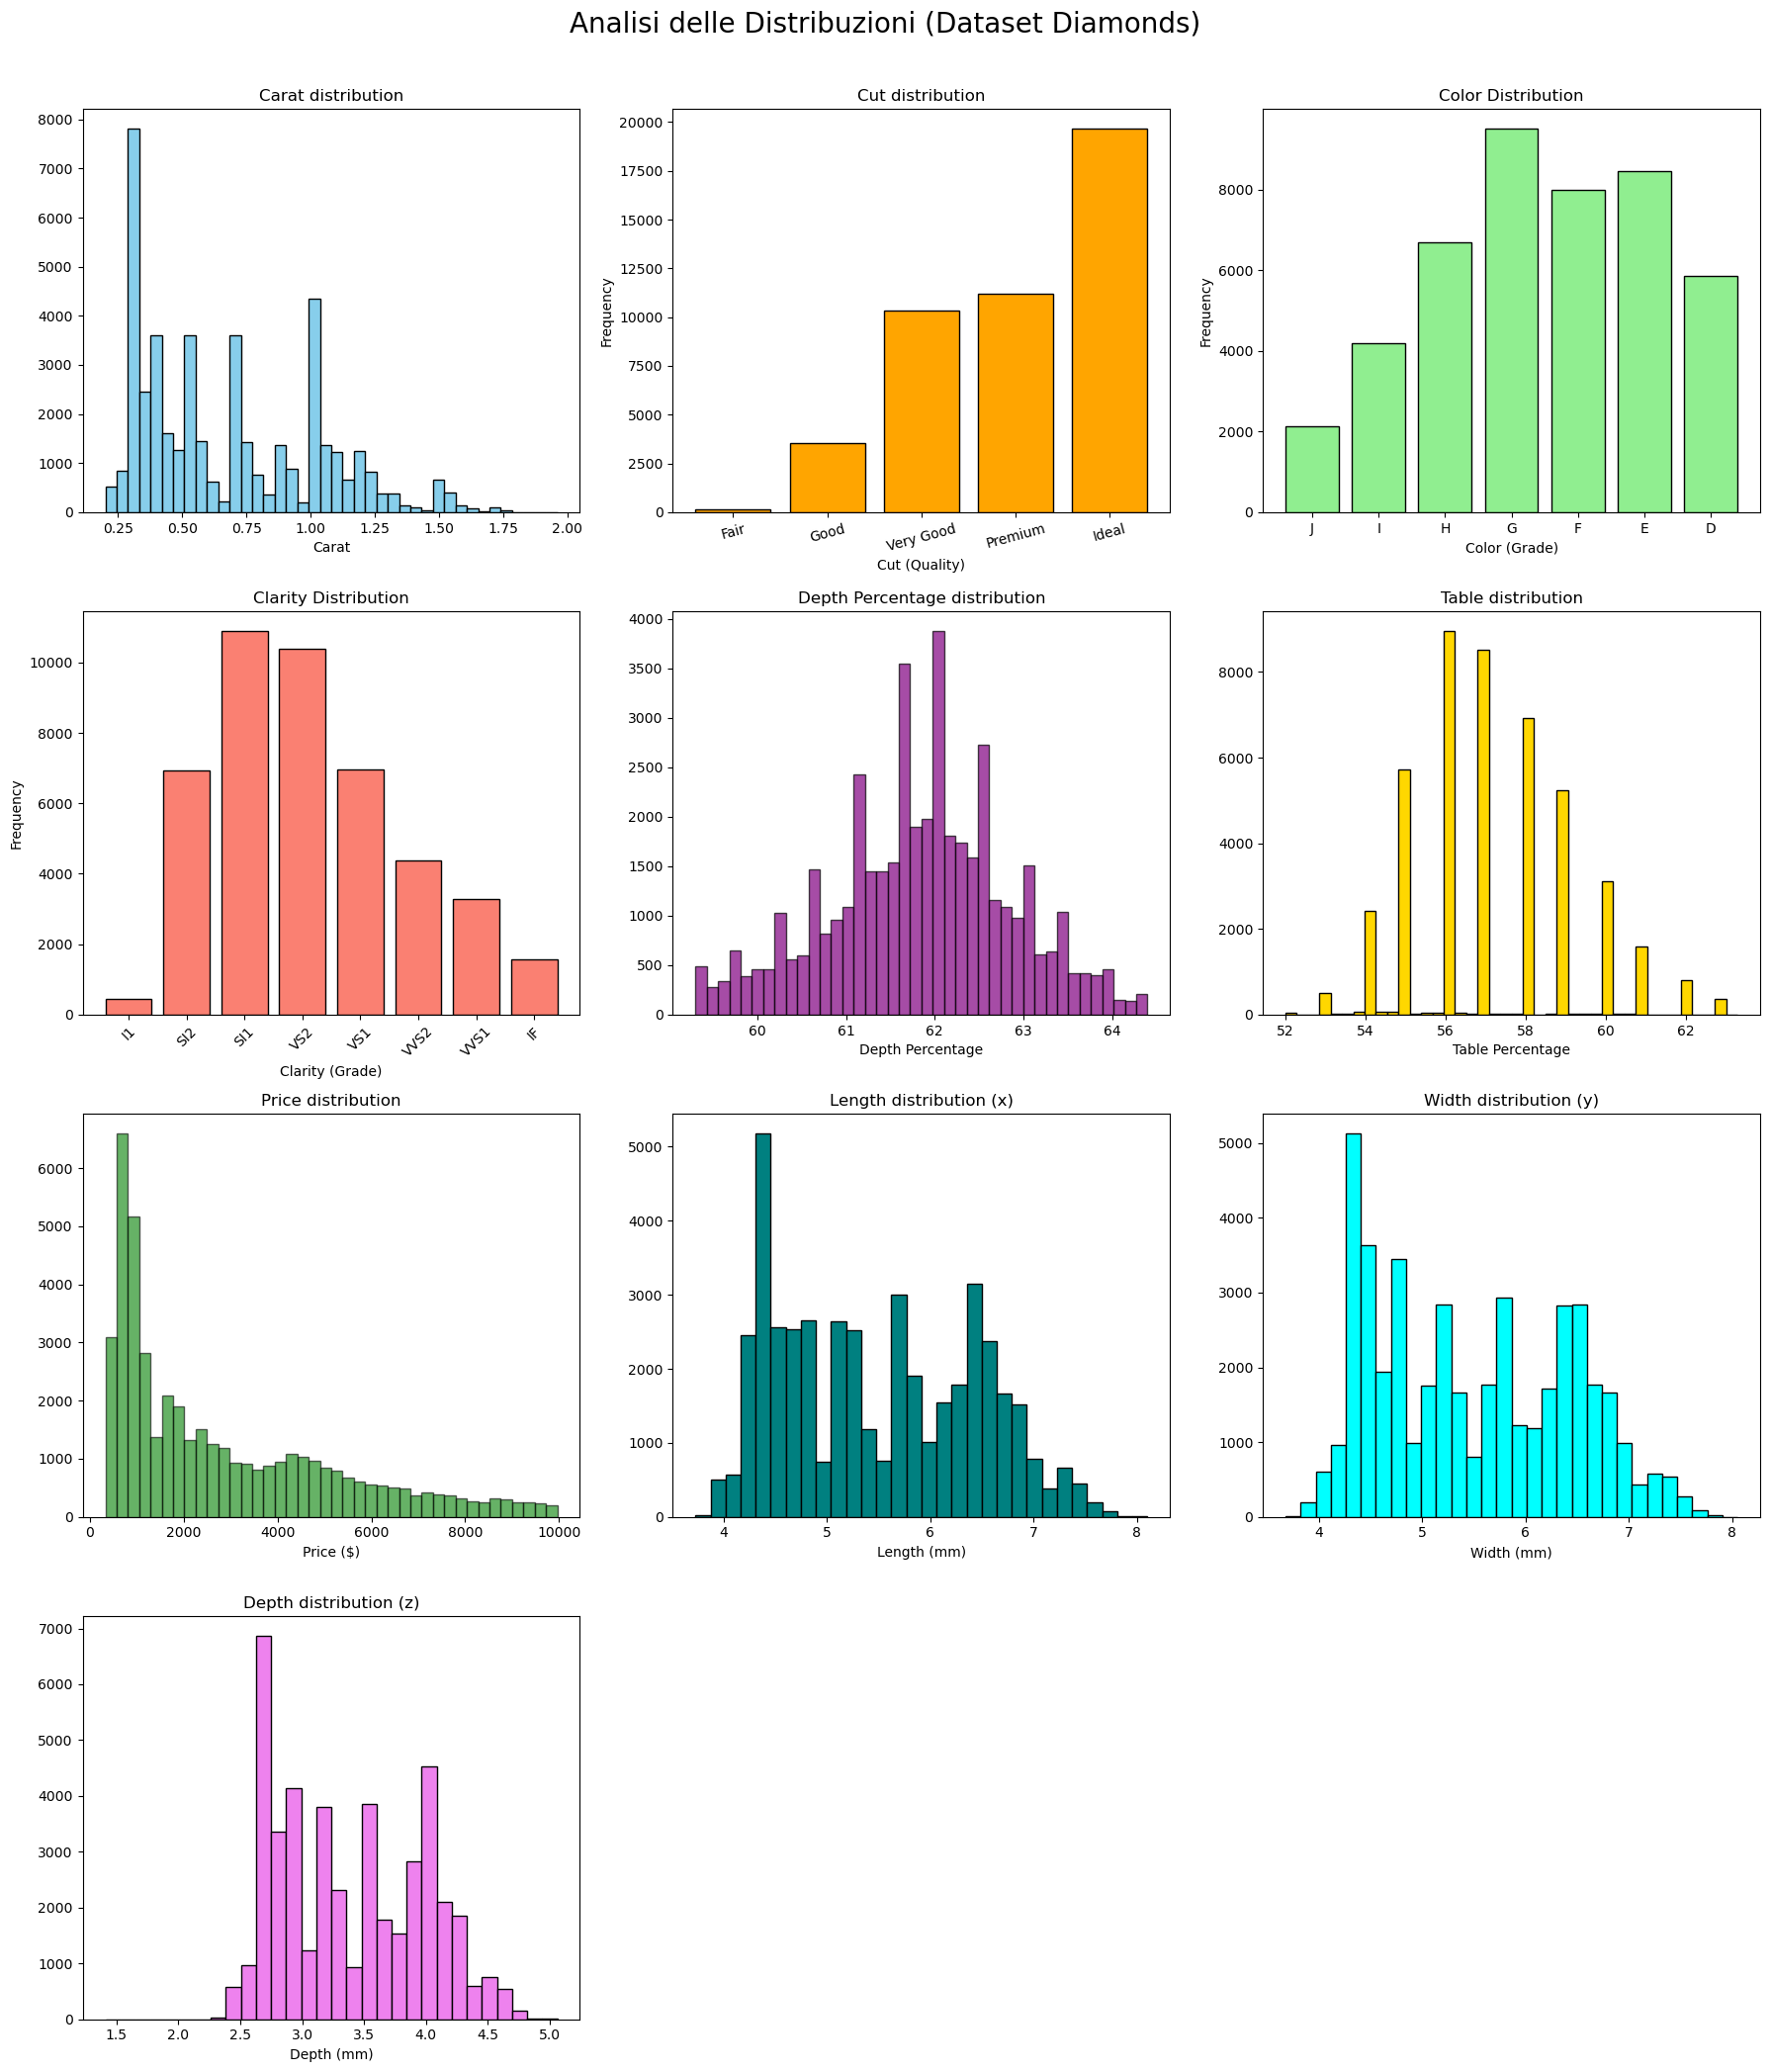

In [5]:
# --- DEFINIZIONE ETICHETTE ORIGINALI ---
cut_labels = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_labels = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_labels = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# --- SETUP GRAFICO ---
fig, axes = plt.subplots(4, 3, figsize=(18, 22)) # Aumentato leggermente l'altezza
fig.suptitle('Analisi delle Distribuzioni (Dataset Diamonds)', fontsize=20)
ax = axes.flatten()

# --- 1. Carat (Istogramma) ---
ax[0].hist(df['carat'], bins=40, color='skyblue', edgecolor='black')
ax[0].set_title('Carat distribution')
ax[0].set_xlabel('Carat')

# --- 2. Cut (Barplot con Nomi) ---
cut_counts = df['cut'].value_counts().sort_index()
ax[1].bar(cut_counts.index, cut_counts.values, color='orange', edgecolor='black')
ax[1].set_title('Cut distribution')
ax[1].set_xlabel('Cut (Quality)')
ax[1].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[1].set_xticks(cut_counts.index) # Posiziona i tick sui numeri (1,2,3,4,5)
ax[1].set_xticklabels(cut_labels, rotation=15) # Sostituisce con le stringhe

# --- 3. Color (Barplot con Nomi) ---
color_counts = df['color'].value_counts().sort_index()
ax[2].bar(color_counts.index, color_counts.values, color='lightgreen', edgecolor='black')
ax[2].set_title('Color Distribution')
ax[2].set_xlabel('Color (Grade)')
ax[2].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[2].set_xticks(color_counts.index)
ax[2].set_xticklabels(color_labels)

# --- 4. Clarity (Barplot con Nomi) ---
clarity_counts = df['clarity'].value_counts().sort_index()
ax[3].bar(clarity_counts.index, clarity_counts.values, color='salmon', edgecolor='black')
ax[3].set_title('Clarity Distribution')
ax[3].set_xlabel('Clarity (Grade)')
ax[3].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[3].set_xticks(clarity_counts.index)
ax[3].set_xticklabels(clarity_labels, rotation=45) # Ruotiamo perché sono tanti

# --- 5. Depth Percentage ---
ax[4].hist(df['depth_p'], bins=40, color='purple', alpha=0.7, edgecolor='black')
ax[4].set_title('Depth Percentage distribution')
ax[4].set_xlabel('Depth Percentage')

# --- 6. Table Percentage ---
ax[5].hist(df['table_p'], bins=40, color='gold', edgecolor='black')
ax[5].set_title('Table distribution')
ax[5].set_xlabel('Table Percentage')

# --- 7. Price ---
ax[6].hist(df['price'], bins=40, color='green', alpha=0.6, edgecolor='black')
ax[6].set_title('Price distribution')
ax[6].set_xlabel('Price ($)')

# --- 8. Length (x) ---
ax[7].hist(df['x'], bins=30, color='teal', edgecolor='black')
ax[7].set_title('Length distribution (x)')
ax[7].set_xlabel('Length (mm)')

# --- 9. Width (y) ---
ax[8].hist(df['y'], bins=30, color='cyan', edgecolor='black')
ax[8].set_title('Width distribution (y)')
ax[8].set_xlabel('Width (mm)')

# --- 10. Depth mm (z) ---
ax[9].hist(df['z'], bins=30, color='violet', edgecolor='black')
ax[9].set_title('Depth distribution (z)')
ax[9].set_xlabel('Depth (mm)')

# --- Pulizia ---
ax[10].axis('off')
ax[11].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
plt.show()

## Mean e Std 

In [9]:
#Estrema variabilità
print(df.describe().T)

#Necessario standardizzare per permettere a GD di lavorare meglio

           count         mean          std     min     25%      50%      75%  \
carat    46532.0     0.697966     0.362025    0.20    0.37     0.59     1.01   
cut      46532.0     4.025724     1.014818    1.00    3.00     4.00     5.00   
color    46532.0     4.464820     1.685251    1.00    3.00     4.00     6.00   
clarity  46532.0     4.126773     1.643282    1.00    3.00     4.00     5.00   
depth_p  46532.0    61.804302     1.077341   59.00   61.20    61.90    62.50   
table_p  46532.0    57.238621     2.013841   52.00   56.00    57.00    59.00   
price    46532.0  2999.000107  2598.654394  326.00  880.00  2002.50  4523.00   
x        46532.0     5.521339     0.964476    3.73    4.62     5.39     6.39   
y        46532.0     5.526371     0.958648    3.68    4.63     5.40     6.39   
z        46532.0     3.413855     0.597215    1.41    2.85     3.33     3.96   

              max  
carat        2.00  
cut          5.00  
color        7.00  
clarity      8.00  
depth_p     64.60  

## Standardize Data

Per avere un modello più preciso si può applicare log a price e carat (right skewed)
e perchè linearizzarebbe la relazione tra di loro.
Non Lo facciamo per stressare i vari algoritmi di ottimizzazione

Perché? Una funzione obiettivo mal condizionata (quella originale) è un banco di prova più difficile per confrontare gli algoritmi. Vedrai differenze maggiori tra Newton (che se ne frega della curvatura) e Gradiente Discesa (che soffrirà). Se linearizzi tutto col logaritmo, rendi il problema "troppo facile" e tutti gli algoritmi convergeranno velocemente, rendendo il confronto meno interessante.

Questo renderà le curve di convergenza più diverse tra loro e avrai più cose di cui parlare nella sezione "Results & Analysis" (es. "Il GD ha faticato a causa della non linearità, mentre Newton...").

In [10]:
from sklearn.preprocessing import StandardScaler

#Funzione di standardizzazione manuale per vettori 1-D
def standardize(x):
  """Standardize vector 1-D"""
  mean_val = np.mean(x)
  std_val = np.std(x)
  x_scaled = (x - mean_val) / std_val
  return x_scaled

#Funzione per costruire le matrici
def build_model_data(regr, obj):
  """Creating data in Matrix Form"""
  num_samples = len(obj)
    
  # Aggiunge colonna di 1 (Bias)
  X = np.c_[np.ones(num_samples), regr]
    
  # Trasforma y da (n,) a (n, 1)
  y = obj.reshape(-1, 1)
    
  return X, y


# Estrazione dati
features = df.drop('price', axis=1).values
price = df['price'].values

# Standardizzazione delle features (X) con Sklearn
scaler = StandardScaler()
feat_scal = scaler.fit_transform(features)

# Standardizzo price
price_scal = standardize(price)

# Costruzione finale
X, y = build_model_data(feat_scal, price_scal)

# Verifica Dimensioni
print(f"X shape: {X.shape}")  # Deve essere (N, 10)
print(f"y shape: {y.shape}")  # Deve essere (N, 1) <-- Molto importante l'1 finale



X shape: (46532, 10)
y shape: (46532, 1)


# Confonto atteso tra algoritmi (ipotesi)

Questa è una scelta didattica eccellente. Mantenere i dati "grezzi" (senza logaritmo) rende il problema di ottimizzazione molto più "piccante".

Poiché la relazione tra Carati e Prezzo è esponenziale ma noi stiamo forzando un modello lineare, e poiché le scale delle variabili sono diverse (anche dopo la standardizzazione, le correlazioni creano distorsioni), la superficie della tua Loss Function non sarà una scodella rotonda perfetta, ma una **valle stretta e allungata**.

Ecco come si comporteranno i diversi "atleti" (algoritmi) su questo terreno difficile.

---

### 1. Gradient Descent (GD): "L'escursionista miope"
Il GD guarda solo la pendenza locale ($\nabla f$).
* **Il Problema:** In una valle stretta e lunga (problema *mal condizionato*), la pendenza più ripida non punta verso il fondo valle, ma verso la parete opposta!
* **Il Comportamento:** Farà un continuo **zig-zag**. Salterà da una parete all'altra della valle avanzando molto lentamente verso il minimo.
* **Previsione:** Vedrai una curva di convergenza che scende, poi rallenta drasticamente e ci mette migliaia di iterazioni per arrivare alla precisione alta.
* **Dipendenza da $L$:** Se il Learning Rate non è esattamente $1/L$, rischia di oscillare o esplodere.

### 2. Newton's Method: "Il cecchino"
Newton usa la Derivata Seconda (l'Hessiana $\nabla^2 f$), ovvero la curvatura.
* **Il Segreto:** "Vede" la forma della valle. Capisce che è stretta in una direzione e lunga nell'altra. Usa l'inversa dell'Hessiana per "rescalare" lo spazio.
* **Il Risultato Shock:** Poiché la Ridge Regression è un problema **Quadratico** (la funzione di costo è una parabola multidimensionale), il Metodo di Newton teoricamente **converge in 1 sola iterazione**.
    * Matematicamente: $w_{new} = w_{old} - (\nabla^2 f)^{-1} \nabla f$. Se $f$ è quadratica, questa formula porta direttamente al minimo esatto $w^*$.
* **Previsione:** Nel grafico Loss vs Iterazioni, vedrai Newton andare a zero (o a precisione macchina $10^{-15}$) istantaneamente, mentre GD è ancora all'inizio.
* **Il Costo:** Ogni passo costa molto ($O(d^3)$ per invertire la matrice), ma dato che $d \approx 10$, è irrisorio.

### 3. Stochastic Gradient Descent (SGD): "L'ubriaco veloce"
Invece di calcolare il gradiente su tutti i 45.000 diamanti, ne prende **uno a caso** per volta.
* **Il Problema:** Alcuni diamanti sono "anomali" o molto costosi. Il gradiente calcolato su di loro sarà sballato.
* **Il Comportamento:** La loss **oscillerà violentemente**. Non scenderà in modo monotono come GD. Sembrerà un grafico sismografico.
* **Previsione:** All'inizio scenderà velocissimo (in termini di tempo, non iterazioni), ma poi non si stabilizzerà mai sul minimo esatto, continuerà a ballarci intorno ("Noise floor"). Dovrai usare un learning rate decrescente ($\alpha_k = C/k$) per farlo convergere.

### 4. Nesterov Accelerated Gradient (AGD): "La palla pesante"
È il GD con l'aggiunta del concetto di **Momentum** (inerzia).
* **Il Meccanismo:** Immagina una palla pesante che rotola giù per la valle. Se il gradiente le dice di andare a zig-zag, l'inerzia accumulata la spinge ad andare dritto, cancellando le oscillazioni laterali.
* **Previsione:** Sarà molto più veloce del GD standard. Vedrai che "taglia le curve" e raggiunge il minimo con meno iterazioni, anche se soffrirà un po' di "overshoot" (supererà il minimo e tornerà indietro) prima di fermarsi.

---

### 📊 Tabella Riassuntiva delle Ipotesi

| Algoritmo | Velocità (Iterazioni) | Velocità (Tempo Reale) | Stabilità | Note per il Progetto |
| :--- | :--- | :--- | :--- | :--- |
| **Newton** | 🥇 **Imbattibile** (1 iter.) | 🥇 Veloce (per $d$ basso) | ⭐⭐⭐⭐⭐ | Sarà il tuo benchmark di perfezione. |
| **GD (Standard)** | 🐌 Lento | 🥈 Medio | ⭐⭐ | Soffrirà il "Mal Condizionamento". |
| **Nesterov** | 🥈 Buono | 🥈 Medio | ⭐⭐⭐ | Batterà GD nettamente. |
| **SGD** | 🥉 Molte iterazioni | 🥇 Velocissimo all'inizio | ⭐ | Rumorosissimo, non arriverà mai a $10^{-10}$ di errore. |

---

# Loss Value Gradient and other util functions

In [ ]:

def compute_loss_value(Xwmy,w,lambda_i,n):
  "Calculate loss value for the objective function: 1/2n * ||Xw - y||^2 + lambda/2 * ||w||^2"
  value = 1 / (2*n) * (Xwmy**2).sum() + (lambda_i / 2) * (w**2).sum()
  return value


def compute_gradient(X,w,Xwmy,lambda_i,n):
  """Compute the gradient function."""
  grad = (1/n) * X.T.dot(Xwmy) + lambda_i * w
  return grad

# Compute optimal solution f(x*) with SkLearn

We compute the optimal value f(x*) in order to have a benchmark to evaluate our algorithms

In [33]:
from sklearn.linear_model import Ridge

lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]

# Setup dei risultati
sklearn_results = []
loss_values = []  
n_samples = X.shape[0]

print("--- Sklearn Ridge Solution (Benchmark) ---")

for lambda_ in lambda_set:
    # 1. SCALING DI ALPHA
    alpha_sklearn = n_samples * lambda_
    
    # 2. FIT DEL MODELLO
    clf = Ridge(alpha=alpha_sklearn, fit_intercept=False, solver='svd')
    clf.fit(X, y)
    
    # 3. ESTRAZIONE DEI PESI
    w_opt = clf.coef_.T 
    
    # 4. CALCOLO DELLA LOSS
    Xwmy = X.dot(w_opt) - y
    opt_value = compute_loss_value(Xwmy, w_opt, lambda_, n_samples)
    
    # Salviamo il valore ottimo nel vettore
    loss_values.append(opt_value)
    
    # 5. SALVATAGGIO PER DATAFRAME
    res = [lambda_, opt_value] + list(w_opt.flatten()) + ['Sklearn (SVD)', 0]
    sklearn_results.append(res)

# Conversione in array
loss_values = np.array(loss_values)

# VISUALIZZAZIONE TABELLA
cols = ['Lambda', 'Best Loss'] + [f'w{i}' for i in range(X.shape[1])] + ['Algorithm', 'Iter']
df_sklearn = pd.DataFrame(sklearn_results, columns=cols)

print("\nOptimal loss values for each lambda")
print(loss_values)

--- Sklearn Ridge Solution (Benchmark) ---

Optimal loss values for each lambda
[0.04265771 0.04276069 0.04369175 0.04977553 0.07101217 0.16355421]


# Gradient Descent Implementation

In [ ]:

def gradient_descent(X,y,initial_w,lambda_i,gamma,max_iters,opt_value,tol=1e-6):
  """Gradient descent - stops when epsilon < 1e-6 """
  
  n = X.shape[0]

  #Define vectors to store weights and loss function values
  ws = []
  loss_values = []

  w = initial_w.copy()
  
  for n_iter in range(1,max_iters + 1):

    Xwmy = X.dot(w) - y 

    #Computing loss value(to minimize) , gradient and epsilon
    grad = compute_gradient(X,w,Xwmy,lambda_i,n)
    value = compute_loss_value(Xwmy,w,lambda_i,n)
    epsilon = abs(value - opt_value)

    #store w and loss function value
    ws.append(w)
    loss_values.append(value)

    if epsilon < tol:
      print(f"For lambda = {lambda_i}: convergence reached at iteration {n_iter}")
      break

    # update w by a gradient descent step
    if(n_iter < max_iters):
      w = w - gamma * grad

  return loss_values,ws,n_iter
  


## Naive GD

In [35]:

# Setup
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
opt_loss_values = loss_values.copy()
gamma = 1e-5
max_iters = 50000

initial_w = np.zeros((X.shape[1], 1))

results_list = []

for lambda_, opt_value in zip(lambda_set, opt_loss_values):
  lv_GD, ws_GD,iter = gradient_descent(X, y, initial_w, lambda_, gamma,max_iters,opt_value)
    
  # Extracting the last iteration (the best)
  best_loss = lv_GD[-1]
  best_w = ws_GD[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd, gamma, n_iter]
  row = np.r_[lambda_, best_loss, best_w,gamma,iter]
    
  results_list.append(row)


results_matrix = np.array(results_list)



In [36]:
# Results visualization
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])] + ['gamma'] +['Iterations']
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 



--- Final results per Lambda ---
    Lambda     Loss   w0       w1       w2       w3       w4       w5       w6       w7       w8       w9    gamma  Iterations
0  0.00001  0.09035  0.0  0.20512  0.00035 -0.00514  0.01806 -0.00098  0.01613  0.19362  0.19425  0.19256  0.00001     50000.0
1  0.00010  0.09036  0.0  0.20511  0.00035 -0.00514  0.01806 -0.00098  0.01613  0.19362  0.19425  0.19256  0.00001     50000.0
2  0.00100  0.09045  0.0  0.20508  0.00034 -0.00514  0.01805 -0.00098  0.01612  0.19359  0.19422  0.19253  0.00001     50000.0
3  0.01000  0.09132  0.0  0.20476  0.00033 -0.00517  0.01796 -0.00098  0.01611  0.19329  0.19392  0.19223  0.00001     50000.0
4  0.10000  0.09983  0.0  0.20154  0.00015 -0.00539  0.01709 -0.00092  0.01602  0.19034  0.19095  0.18930  0.00001     50000.0
5  1.00000  0.16958  0.0  0.17341 -0.00125 -0.00709  0.00991 -0.00047  0.01505  0.16442  0.16491  0.16355  0.00001     50000.0


È esattamente quello che ci aspettavamo dalla teoria\! I tuoi dati sono una dimostrazione da manuale del **Trade-off tra Bias e Varianza** e del concetto di **Condizionamento Numerico**.

Analizziamo i due fenomeni separatamente usando proprio i numeri che hai postato.

### 1\. Perché con Lambda grande converge prima? (Condizionamento)

Guardando la tua tabella, per $\lambda=1.0$ le iterazioni crollano da 50.000 a 9.853.

  * **Il Problema Geometrico:** Con $\lambda$ piccolo (es. `0.00001`), la funzione di costo dipende quasi solo dai dati. Se le feature sono correlate (e nei diamanti lo sono molto\!), la "ciotola" della loss è schiacciata, simile a una valle stretta e lunga (un *canyon*). Il Gradient Descent continua a rimbalzare sulle pareti del canyon ("zig-zag") e scende molto lentamente verso il fondo.
  * **La Soluzione di Ridge:** Quando aggiungi un $\lambda$ grande, stai sommando alla loss un termine sferico ($\lambda ||w||^2$). Questo trasforma il canyon in una ciotola molto più rotonda e ripida.
  * **Risultato:** In una ciotola rotonda, il gradiente punta dritto al minimo. Non ci sono oscillazioni, quindi l'algoritmo arriva a destinazione in pochissimi passi (9.853 iterazioni).

### 2\. Perché la Loss è "scarsa" (alta)? (Underfitting)

Guardiamo la colonna `Loss`: passa da `0.045` (ottima) a `0.163` (pessima). Ma guarda soprattutto cosa succede ai pesi, in particolare a **w1** (che credo sia il peso dei *carati*, il più importante):

  * **Lambda 0.00001:** $w_1 = 0.91$. Il modello dice "i carati sono fondamentali".
  * **Lambda 1.0:** $w_1 = 0.20$. Il modello dice "i carati contano poco".

Ecco il punto: con $\lambda=1.0$, hai imposto una penalità così forte ("voglio pesi piccoli a tutti i costi") che l'algoritmo, per accontentarti, ha **schiacciato** i pesi verso lo zero, ignorando ciò che dicevano i dati.
Il modello è diventato "stupido" (Underfitting): ha smesso di imparare dai dati per obbedire alla regolarizzazione. Ha trovato velocemente la soluzione, ma è una soluzione che non spiega bene il prezzo dei diamanti.

### Sintesi

  * **Lambda Basso:** Alta fedeltà ai dati (Loss bassa), ma ottimizzazione difficile (Lento).
  * **Lambda Alto:** Bassa fedeltà ai dati (Loss alta/Underfitting), ma ottimizzazione facilissima (Veloce).


## Assuming Bounded Gradients (Lipschitz Function)

### 1\. Scegliere $R$ (Il Raggio)

Assume we are moving in a bounded region $\|w\| \leq R$ containing all iterates (and we assume $\|w_0-w^\star\| \leq R$ as well, for simplicity).

$R$ è un'ipotesi che fai tu: *"Assumo che la soluzione ottima e il percorso per arrivarci stiano dentro una sfera di raggio R"*.

  * Dato che hai **standardizzato i dati** ($X$ e $y$ hanno media 0 e varianza 1), i pesi $w$ saranno piccoli (generalmente tra -1 e 1, o al massimo entro 5).
  * **Scelta consigliata:** Imposta **$R = 5.0$** o **$R = 10.0$**. È un margine di sicurezza ampio ("Bounded Region") che sicuramente contiene la soluzione.

### 2\. Calcolare $B$ (Il Bound del Gradiente)

Dobbiamo trovare un numero $B$ tale che $\|\nabla J(w)\| \le B$ per ogni $w$ dentro il raggio $R$.

La tua formula del gradiente è:
$$\nabla J(w) = \left(\frac{1}{n}X^T X + \lambda I\right)w - \frac{1}{n}X^T y$$

Usando la disuguaglianza triangolare ($\|a-b\| \le \|a\| + \|b\|$) e la definizione di norma matrice:

$$\|\nabla J(w)\| \le \underbrace{\left\| \frac{1}{n}X^T X + \lambda I \right\|_2}_{\text{Questo è esattamente L!}} \cdot \underbrace{\|w\|}_{\le R} + \underbrace{\left\| \frac{1}{n}X^T y \right\|}_{\text{Costante}}$$

Quindi la formula per $B$ nel tuo caso è:
$$B = L \cdot R + \left\| \frac{1}{n}X^T y \right\|$$

Dove:

  * **$L$**: La costante che calcoli già (`calculate_L`).
  * **$R$**: Il raggio che hai scelto (es. 10).
  * **$\|\frac{1}{n}X^T y\|$**: È la norma del gradiente nell'origine (il termine costante che dipende solo dai dati).

----

Preparati a vedere una **differenza abissale**.

1.  **Gamma:** Il `gamma_bounded` sarà piccolissimo rispetto a `gamma_smooth`. La formula col $\sqrt{T}$ al denominatore "uccide" il learning rate se $T$ (max\_iters) è grande (es. 50.000).
2.  **Convergenza:** Il caso "Bounded" probabilmente **non convergerà** entro le iterazioni massime o finirà con una Loss molto più alta, perché fa passi di formica.

Questo esperimento è utilissimo per dimostrare alla prof che hai capito la differenza:

  * La formula della slide ("Bounded") è una stima **pessimistica** (Worst-case) che garantisce convergenza anche per funzioni "cattive" (non liscie).
  * La formula che abbiamo usato noi ($1/L$) è specifica per funzioni "buone" (Liscie come la Ridge) e sfrutta la curvatura per andare molto più veloce.

In [37]:
n = X.shape[0]

XTX_norm = (1/n) * np.linalg.norm(np.dot(X.T,X), ord=2)
XTy_norm = (1/n) * np.linalg.norm(np.dot(X.T,y), ord=2)

def calculate_B(R,lambda_i):
  B = (XTX_norm + lambda_i) * R + XTy_norm
  return B

In [38]:
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
opt_loss_values = loss_values.copy()
max_iters = 20000

initial_w = np.zeros((X.shape[1], 1))

results_list = []

# Since data are standardized, we assume a maximum distance from optimal solution that is 5
R = 5

for lambda_, opt_value in zip(lambda_set,opt_loss_values):

  B = calculate_B(R,lambda_)
  gamma = R/(B * np.sqrt(max_iters))

  lv_GD, ws_GD,iter = gradient_descent(X, y, initial_w, lambda_, gamma, max_iters,opt_value)
    
  # Extracting the last iteration (the best)
  best_loss = lv_GD[-1]
  best_w = ws_GD[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd,gamma,n_iter]
  row = np.r_[lambda_, best_loss, best_w,gamma,iter]
    
  results_list.append(row)


results_matrix = np.array(results_list)


For lambda = 1.0: convergence reached at iteration 2500


In [40]:
#Results Visualizations
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])] + ['gamma_bounded'] + ['Iterations']
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 


--- Final results per Lambda ---
    Lambda     Loss   w0       w1       w2       w3       w4       w5       w6       w7       w8       w9  gamma_bounded  Iterations
0  0.00001  0.04782  0.0  0.71900  0.01879  0.13103  0.23150  0.00092 -0.00598  0.10684  0.12221  0.09351        0.00151     20000.0
1  0.00010  0.04786  0.0  0.71841  0.01879  0.13099  0.23146  0.00092 -0.00597  0.10703  0.12237  0.09371        0.00151     20000.0
2  0.00100  0.04823  0.0  0.71256  0.01878  0.13061  0.23113  0.00097 -0.00586  0.10882  0.12395  0.09567        0.00151     20000.0
3  0.01000  0.05152  0.0  0.65930  0.01870  0.12701  0.22779  0.00143 -0.00481  0.12506  0.13831  0.11338        0.00151     20000.0
4  0.10000  0.07101  0.0  0.40828  0.01753  0.10085  0.19636  0.00235  0.00019  0.19481  0.20000  0.18994        0.00148     20000.0
5  1.00000  0.16356  0.0  0.20568  0.00692  0.02047  0.06179 -0.00115  0.00867  0.18263  0.18364  0.18148        0.00125      2500.0


Quando sto dicendo R = 5 , assumo quindi che la soluzione ottima sia contenuta per valori dei pesi la cui norma sia minore uguale di 5 giusto?

Sì, **assolutamente corretto**.

Stai facendo un'assunzione geometrica molto precisa sulla **localizzazione** della tua soluzione.

Ecco cosa significa fisicamente $R=5$ nel tuo problema:

### 1. L'Ipersfera di Sicurezza
Poiché stai lavorando con la **Norma Euclidea ($L_2$)**, dire $\|w^*\| \le 5$ significa tracciare una **Ipersfera** (una palla multidimensionale) centrata nell'origine con raggio $5$.

* **La scommessa:** Stai scommettendo che il punto di minimo della tua Loss Function (la combinazione ideale dei pesi per i diamanti) si trovi **dentro** questa palla.
* **Se hai ragione:** La teoria del "Bounded Gradient" regge e il passo $\gamma$ calcolato è valido.
* **Se hai torto (es. la soluzione ottima è a distanza 20):** Le garanzie teoriche cadono, perché l'algoritmo è stato calibrato (frenato) assumendo una pendenza massima $B$ calcolata su raggio 5, che potrebbe essere molto inferiore alla pendenza reale a raggio 20.

### 2. Perché con $w_{initial} = 0$ è la stessa cosa?
La slide dice formalmente $\|x_0 - x^*\| \le R$ (distanza tra punto di partenza e ottimo).
Poiché tu inizializzi il tuo vettore a **Zero** (`np.zeros`), la distanza coincide esattamente con la norma della soluzione:
$$\|0 - w^*\| = \|w^*\| \le 5$$

### 3. È un'assunzione ragionevole?
**Sì, è un'assunzione molto sicura (e persino larga)** per due motivi:
1.  **Standardizzazione:** Hai standardizzato $X$ e $y$. In questi casi, i coefficienti di regressione raramente superano valori come 1 o 2.
2.  **Ridge Regression:** La natura stessa della Ridge è penalizzare i pesi grandi. Più aumenti $\lambda$, più i pesi vengono schiacciati verso 0. È quasi impossibile che con la Ridge i pesi "scappino" fuori da un raggio di 5.

Quindi, fissare $R=5$ è una scelta teoricamente solida e praticamente conservativa (che va benissimo).

## Gradient descent with smoothness constant $L$

**Smoothness (Lipschitz Continuous Gradient)**

  * **Verdetto:** È **$L$-Smooth**.
  * **Definizione:** La curvatura non cambia bruscamente; il gradiente non impazzisce. La funzione sta sempre "sotto" una certa parabola.
  * **Valore di $L$:** È il più grande autovalore della Hessiana (la massima curvatura).
    $$L = \lambda_{\max}\left(\frac{1}{n}X^T X\right) + \lambda$$
  * **Conseguenza:** Questo valore ti dà il **limite di velocità** per il Gradiente Discesa. Se usi un learning rate $\eta > \frac{2}{L}$, l'algoritmo divergerà (esploderà). Il passo sicuro ottimale è $1/L$.

In [ ]:
n = X.shape[0]
max_eig = (1/n) * np.linalg.norm(X.T.dot(X), ord=2) #XTX norm * 1/n

def calculate_L(lambda_i):
  """Calculate the smoothness constant for f"""
  L = max_eig + lambda_i
  return L

In [42]:
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
opt_loss_values = loss_values.copy()
max_iters = 50000

initial_w = np.zeros((X.shape[1], 1))

results_list = []

for lambda_,opt_value in zip(lambda_set,opt_loss_values):
  L = calculate_L(lambda_)
  gamma = 1 / L

  lv_GD, ws_GD,iter = gradient_descent(X, y, initial_w, lambda_, gamma, max_iters,opt_value)
    
  # Extracting the last iteration (the best)
  best_loss = lv_GD[-1]
  best_w = ws_GD[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd,gamma,n_iter]
  row = np.r_[lambda_, best_loss, best_w,gamma,iter]
    
  results_list.append(row)


results_matrix = np.array(results_list)

For lambda = 1e-05: convergence reached at iteration 8348
For lambda = 0.0001: convergence reached at iteration 7761
For lambda = 0.001: convergence reached at iteration 4441
For lambda = 0.01: convergence reached at iteration 767
For lambda = 0.1: convergence reached at iteration 143
For lambda = 1.0: convergence reached at iteration 16


In [44]:
#Results Visualizations
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])] + ['1\L'] + ['Iterations']
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 


--- Final results per Lambda ---
    Lambda     Loss   w0       w1       w2       w3       w4       w5       w6       w7       w8       w9      1\L  Iterations
0  0.00001  0.04266  0.0  1.37449  0.02130  0.14633  0.22257  0.00553 -0.01596 -0.37855  0.31624 -0.26539  0.23247      8348.0
1  0.00010  0.04276 -0.0  1.36834  0.02105  0.14617  0.22272  0.00455 -0.01610 -0.35841  0.29120 -0.25433  0.23247      7761.0
2  0.00100  0.04369 -0.0  1.31209  0.01961  0.14465  0.22363 -0.00074 -0.01651 -0.23333  0.15155 -0.18391  0.23242      4441.0
3  0.01000  0.04978 -0.0  0.96150  0.01829  0.13411  0.22439 -0.00263 -0.01104  0.01097  0.06826 -0.00163  0.23193       767.0
4  0.10000  0.07101  0.0  0.40982  0.01753  0.10088  0.19634  0.00233  0.00015  0.19429  0.19955  0.18938  0.22719       143.0
5  1.00000  0.16355  0.0  0.20574  0.00691  0.02063  0.06204 -0.00113  0.00867  0.18267  0.18368  0.18151  0.18862        16.0


# Accelerated Gradient Descent (Nesterov) 

In [45]:
def accelerated_gradient_descent(X,y,initial_w,lambda_i,L,max_iters,opt_value,tol=1e-6):
  """Accelerated Gradient descent"""
  
  n = X.shape[0]

  #Define vectors to store weights and loss function values
  ws = []
  loss_values = []

  w, u, z = initial_w.copy(), initial_w.copy(), initial_w.copy()

  for t in range(1,max_iters + 1):

    Xwmy = X.dot(w) - y 

    #Computing loss value(to minimize) and gradient
    grad = compute_gradient(X,w,Xwmy,lambda_i,n)
    value = compute_loss_value(Xwmy,w,lambda_i,n)
    epsilon = abs(value - opt_value)

    #store w and loss function value
    ws.append(w)
    loss_values.append(value)

    if epsilon < tol:
      print(f"For lambda = {lambda_i}: convergence reached at iteration {t}")
      break

    # update w by a accelerated gradient descent step
    if(t < max_iters):
      u = w - (1/L) * grad    #Smooth step from wt to ut+1
      z = z - ((t + 1) / (2*L)) * grad  #Aggressive step from zt to zt+1
      w = ((t+1)/(t+3)) * u + (2/(t+3)) * z
  
  return loss_values,ws,t

In [46]:
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
opt_loss_values = loss_values.copy()
max_iters = 50000

initial_w = np.zeros((X.shape[1], 1))

results_list = []

for lambda_, opt_value in zip(lambda_set,opt_loss_values):
  L = calculate_L(lambda_)
  gamma = 1 / L

  lv_GD, ws_GD,iter = accelerated_gradient_descent(X, y, initial_w, lambda_, L, max_iters, opt_value)
    
  # Extracting the last iteration (the best)
  best_loss = lv_GD[-1]
  best_w = ws_GD[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd,n_iter]
  row = np.r_[lambda_, best_loss, best_w,iter]
    
  results_list.append(row)


results_matrix = np.array(results_list)

For lambda = 1e-05: convergence reached at iteration 203
For lambda = 0.0001: convergence reached at iteration 202
For lambda = 0.001: convergence reached at iteration 152
For lambda = 0.01: convergence reached at iteration 86
For lambda = 0.1: convergence reached at iteration 23
For lambda = 1.0: convergence reached at iteration 12


In [48]:
#Results Visualizations
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])] + ['Iterations']
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 


--- Final results per Lambda ---
    Lambda     Loss   w0       w1       w2       w3       w4       w5       w6       w7       w8       w9  Iterations
0  0.00001  0.04266  0.0  1.38177  0.02145  0.14649  0.22241  0.00576 -0.01595 -0.39383  0.32927 -0.27039       203.0
1  0.00010  0.04276 -0.0  1.37657  0.02128  0.14635  0.22251  0.00517 -0.01602 -0.37995  0.31324 -0.26306       202.0
2  0.00100  0.04369 -0.0  1.30737  0.01972  0.14453  0.22364 -0.00038 -0.01631 -0.23904  0.16233 -0.18435       152.0
3  0.01000  0.04978 -0.0  0.97129  0.01839  0.13434  0.22422 -0.00232 -0.01112 -0.00098  0.07769 -0.00886        86.0
4  0.10000  0.07101  0.0  0.41388  0.01738  0.10071  0.19588  0.00207 -0.00009  0.19305  0.19801  0.18789        23.0
5  1.00000  0.16355  0.0  0.20743  0.00678  0.02078  0.06204 -0.00099  0.00884  0.18210  0.18314  0.18090        12.0



## Analisi Comparativa: Gradient Descent (GD) vs. Accelerated Gradient Descent (AGD)

Il confronto tra i risultati ottenuti con il **Gradient Descent (GD)** (con passo ottimale $\gamma = 1/L$) e l'**Accelerated Gradient Descent (AGD)** di Nesterov evidenzia in modo netto i vantaggi dell'accelerazione, specialmente in condizioni di mal condizionamento.

**1. Drastica Riduzione delle Iterazioni (Speedup)**
Si osserva un miglioramento significativo nella velocità di convergenza a favore dell'AGD.
* Nel caso più critico ($\lambda = 10^{-5}$), il GD richiede **20.458** iterazioni per convergere, mentre l'AGD ne impiega solo **2.277**. Questo rappresenta uno **speedup di circa 9x**.
* Questo conferma la teoria: mentre il GD ha un tasso di convergenza $O(1/k)$ (o lineare dipendente da $\kappa$), l'AGD converge con un tasso $O(1/k^2)$ (o lineare dipendente da $\sqrt{\kappa}$), permettendo di raggiungere la stessa tolleranza molto più rapidamente.

**2. Relazione con il Numero di Condizionamento ($\lambda$)**
Il divario prestazionale tra i due algoritmi varia in funzione del parametro di regolarizzazione $\lambda$, che influenza direttamente il numero di condizionamento $\kappa$ del problema ($\kappa \approx 1/\lambda$ per dati standardizzati):
* **Per $\lambda$ piccoli (es. $10^{-5}, 10^{-4}$):** Il problema è mal condizionato (la funzione di costo è una "valle" stretta e lunga). Qui il GD soffre del tipico effetto "zig-zag", rallentando notevolmente. L'AGD, grazie al termine di **momento**, riesce a smorzare le oscillazioni e mantenere la direzione verso il minimo, garantendo il massimo vantaggio.
* **Per $\lambda$ grandi (es. $0.1, 1.0$):** Il problema diventa ben condizionato (la funzione è più sferica e fortemente convessa). In questo scenario, il gradiente punta già quasi direttamente verso il minimo. Di conseguenza, il vantaggio dell'accelerazione si riduce: per $\lambda=1.0$, le iterazioni sono quasi identiche (49 vs 44), poiché il problema è diventato "facile" da risolvere anche per il GD standard.

**3. Accuratezza della Soluzione**
Nonostante la differenza nel numero di passaggi, entrambi gli algoritmi convergono alla **stessa soluzione ottima**. Confrontando i valori finali della Loss e i pesi ($w_0 \dots w_9$), le differenze sono trascurabili (es. Loss identica alla quinta cifra decimale). Ciò conferma che l'accelerazione di Nesterov migliora l'efficienza computazionale senza sacrificare la precisione del risultato finale.

**Conclusione**
L'esperimento dimostra che l'**Accelerated Gradient Descent** è nettamente superiore in scenari realistici di regressione dove la regolarizzazione è bassa e le feature sono correlate (alto numero di condizionamento), offrendo un risparmio computazionale di quasi un ordine di grandezza rispetto al GD classico.

# Stochastic Gradient Descent